In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_regression
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [63]:
## Making the regression
X,y = make_regression(n_features=5,n_samples=100,n_informative=5, random_state=42, n_targets=1)

In [64]:
df = pd.DataFrame(X,columns=["col1","col2","col3","col4","col5"])
df['target'] = y

print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.937825,0.515048,0.515035,3.852731,0.513786,271.316121
1,1.088951,-0.715304,0.064280,0.679598,-1.077745,6.230541
2,-0.601707,-1.057711,1.852278,0.822545,-0.013497,11.861024
3,0.821903,0.091761,0.087047,-1.987569,-0.299007,-63.940576
4,1.549934,0.813517,-0.783253,-1.230864,-0.322062,49.630085


In [65]:
def sample_row(data,percentage):
    return data.sample(int(data.shape[0] * percentage), replace=True)

def sample_column(data,percentage):
    new_cols = data.drop(columns=["target"]).sample(n=int((data.shape[1]-1) * 0.5), axis=1, replace=True)
    final_cols = pd.concat([new_cols,df["target"]],axis=1)
    return final_cols

def combination(data,row_p,col_p):
    new_df  = sample_row(data,row_p)
    return sample_column(data,col_p)
    

In [66]:
df.sample(n=int((df.shape[1]-1) * 0.5), axis=1, replace=True)

,col1,col5
0,-0.937825,0.513786
1,1.088951,-1.077745
2,-0.601707,-0.013497
3,0.821903,-0.299007
4,1.549934,-0.322062
...,...,...
95,0.232050,-1.407464
96,-1.415371,-0.342715
97,0.404051,0.174578
98,-0.926930,-3.241267


In [67]:
df1= combination(df,0.5,0.5)
df2= combination(df,0.5,0.5)
df3= combination(df,0.5,0.5)

print(df1.columns, "\n" , df2.columns , "\n" , df3.columns)

Index(['col1', 'col3', 'target'], dtype='str') 
 Index(['col3', 'col3', 'target'], dtype='str') 
 Index(['col1', 'col2', 'target'], dtype='str')


In [68]:
cl1 = DecisionTreeRegressor()
cl2 = DecisionTreeRegressor()
cl3 = DecisionTreeRegressor()

In [69]:
cl1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
cl2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
cl3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.5306193946188341, 0.9615384615384616, 'x[1] <= 0.483\nsquared_error = 19575.816\nsamples = 100\nvalue = 8.842'),
 Text(0.2438340807174888, 0.8846153846153846, 'x[0] <= -0.432\nsquared_error = 14680.297\nsamples = 64\nvalue = -46.107'),
 Text(0.38722673766816146, 0.9230769230769231, 'True  '),
 Text(0.0633408071748879, 0.8076923076923077, 'x[0] <= -0.466\nsquared_error = 13536.561\nsamples = 23\nvalue = -120.296'),
 Text(0.05437219730941704, 0.7307692307692307, 'x[0] <= -1.757\nsquared_error = 11834.207\nsamples = 22\nvalue = -110.258'),
 Text(0.017937219730941704, 0.6538461538461539, 'x[1] <= -0.089\nsquared_error = 13438.411\nsamples = 2\nvalue = -7.88'),
 Text(0.008968609865470852, 0.5769230769230769, 'squared_error = 0.0\nsamples = 1\nvalue = -123.804'),
 Text(0.026905829596412557, 0.5769230769230769, 'squared_error = 0.0\nsamples = 1\nvalue = 108.045'),
 Text(0.09080717488789238, 0.6538461538461539, 'x[1] <= -0.623\nsquared_error = 10520.843\nsamples = 20\nvalue = -120.496'

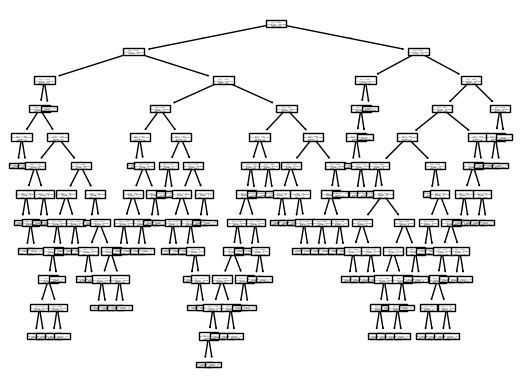

In [70]:
plot_tree(cl1)

[Text(0.5970281092964824, 0.9736842105263158, 'x[1] <= 0.483\nsquared_error = 19575.816\nsamples = 100\nvalue = 8.842'),
 Text(0.4495524497487437, 0.9210526315789473, 'x[0] <= -0.047\nsquared_error = 14680.297\nsamples = 64\nvalue = -46.107'),
 Text(0.5232902795226131, 0.9473684210526316, 'True  '),
 Text(0.39533605527638194, 0.868421052631579, 'x[1] <= -0.066\nsquared_error = 14583.133\nsamples = 43\nvalue = -59.827'),
 Text(0.3852858040201005, 0.8157894736842105, 'x[0] <= -0.09\nsquared_error = 13581.631\nsamples = 42\nvalue = -54.226'),
 Text(0.3752355527638191, 0.7631578947368421, 'x[1] <= -0.111\nsquared_error = 13190.4\nsamples = 41\nvalue = -58.374'),
 Text(0.3651853015075377, 0.7105263157894737, 'x[0] <= -0.145\nsquared_error = 12839.364\nsamples = 40\nvalue = -54.299'),
 Text(0.3283605527638191, 0.6578947368421053, 'x[1] <= -0.47\nsquared_error = 11961.147\nsamples = 38\nvalue = -61.269'),
 Text(0.2848618090452261, 0.6052631578947368, 'x[0] <= -0.527\nsquared_error = 9805.971\

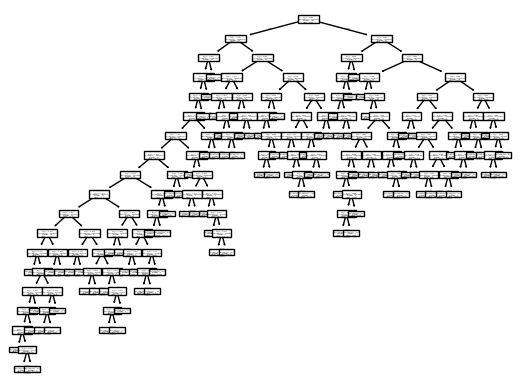

In [71]:
plot_tree(cl2)

[Text(0.5362970132743363, 0.9666666666666667, 'x[1] <= 0.353\nsquared_error = 19575.816\nsamples = 100\nvalue = 8.842'),
 Text(0.27364491150442477, 0.9, 'x[0] <= -0.424\nsquared_error = 13463.15\nsamples = 61\nvalue = -56.581'),
 Text(0.4049709623893806, 0.9333333333333333, 'True  '),
 Text(0.08849557522123894, 0.8333333333333334, 'x[1] <= -1.287\nsquared_error = 11560.412\nsamples = 23\nvalue = -124.042'),
 Text(0.04424778761061947, 0.7666666666666667, 'x[0] <= -0.842\nsquared_error = 1819.809\nsamples = 2\nvalue = -298.48'),
 Text(0.035398230088495575, 0.7, 'squared_error = 0.0\nsamples = 1\nvalue = -255.82'),
 Text(0.05309734513274336, 0.7, 'squared_error = -0.0\nsamples = 1\nvalue = -341.139'),
 Text(0.13274336283185842, 0.7666666666666667, 'x[0] <= -0.762\nsquared_error = 9314.148\nsamples = 21\nvalue = -107.429'),
 Text(0.07079646017699115, 0.7, 'x[1] <= -0.516\nsquared_error = 7464.442\nsamples = 12\nvalue = -141.112'),
 Text(0.035398230088495575, 0.6333333333333333, 'x[0] <= -0

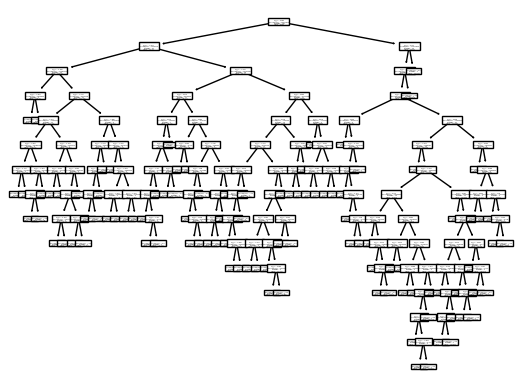

In [72]:
plot_tree(cl3)

In [73]:
df3

,col1,col2,target
0,-0.937825,0.515048,271.316121
1,1.088951,-0.715304,6.230541
2,-0.601707,-1.057711,11.861024
3,0.821903,0.091761,-63.940576
4,1.549934,0.813517,49.630085
...,...,...,...
95,0.232050,-0.718444,-201.590040
96,-1.415371,-0.802277,-216.550869
97,0.404051,0.257550,160.872392
98,-0.926930,-1.024388,-295.047430


In [89]:
n1 =cl1.predict(np.array([-0.937825,0.515048]).reshape(1,2)).tolist()
n2 = cl2.predict(np.array([-0.937825,0.515048]).reshape(1,2)).tolist()
n3 = cl3.predict(np.array([-0.937825,0.515048]).reshape(1,2)).tolist()
n = np.array([n1,n2,n3])

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [90]:
np.mean(n)

np.float64(283.12756934216867)

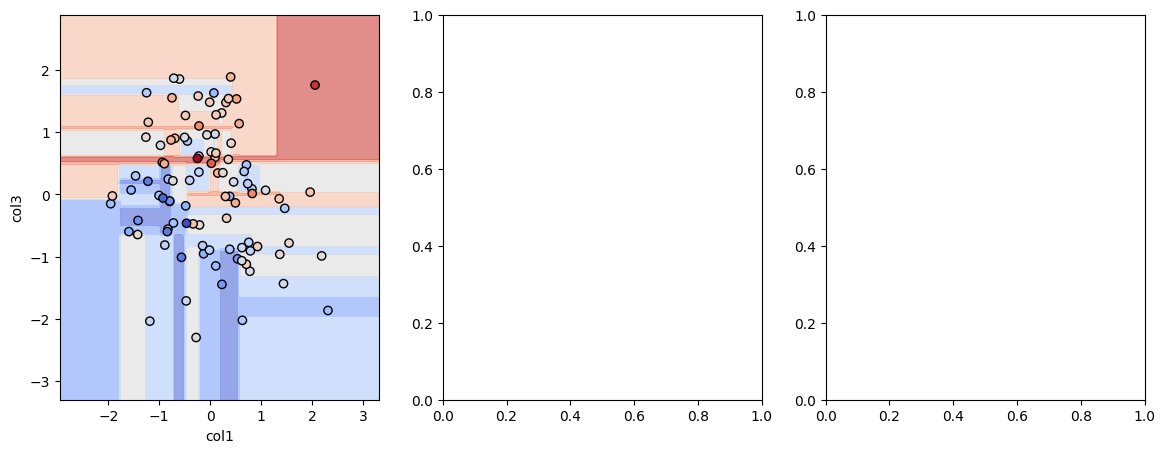

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

DecisionBoundaryDisplay.from_estimator(
    cl1,
    df1.iloc[:,0:2],
    plot_method='contourf',          
    response_method='predict',        
    alpha=0.6,
    cmap='coolwarm',
    ax=axes[0],
)

axes[0].scatter(df1.iloc[:, 0], df1.iloc[:, 1], c=y, cmap="coolwarm", edgecolors="k")